In [1]:
import tensorflow as tf
print(tf.__version__)

2.20.0


In [2]:
# Import basic libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
dataset= pd.read_csv('Churn_Modelling.csv')
dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
# Devide the dataset into independant and depndent features
X= dataset.iloc[:,3:13]
y= dataset.iloc[:,13]

In [5]:
X

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10
...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77
9997,709,France,Female,36,7,0.00,1,0,1,42085.58
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52


In [6]:
y


0       1
1       0
2       1
3       0
4       0
       ..
9995    0
9996    0
9997    1
9998    1
9999    0
Name: Exited, Length: 10000, dtype: int64

In [7]:
## Feature engineering

X['Geography'].nunique()

3

In [8]:
X = pd.get_dummies(X, columns=['Geography'], drop_first=True,dtype=int)


In [9]:
X=pd.get_dummies(X,columns=['Gender'],drop_first=True,dtype=int)
X

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,0,0,0
1,608,41,1,83807.86,1,0,1,112542.58,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,0,0,0
3,699,39,1,0.00,2,0,0,93826.63,0,0,0
4,850,43,2,125510.82,1,1,1,79084.10,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,0,1
9996,516,35,10,57369.61,1,1,1,101699.77,0,0,1
9997,709,36,7,0.00,1,0,1,42085.58,0,0,0
9998,772,42,3,75075.31,2,1,0,92888.52,1,0,1


In [10]:
# Train Test Split

from sklearn.model_selection import train_test_split

X_train, X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=0)



In [11]:
from sklearn.preprocessing import StandardScaler

sc= StandardScaler()
X_train=sc.fit_transform(X_train)
X_test=sc.transform(X_test)

In [12]:
X_test

array([[-0.55204276, -0.36890377,  1.04473698, ...,  1.75486502,
        -0.57369368, -1.09168714],
       [-1.31490297,  0.10961719, -1.031415  , ..., -0.5698444 ,
        -0.57369368, -1.09168714],
       [ 0.57162971,  0.30102557,  1.04473698, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       ...,
       [-0.74791227, -0.27319958, -1.37744033, ..., -0.5698444 ,
         1.74309049,  0.91601335],
       [-0.00566991, -0.46460796, -0.33936434, ...,  1.75486502,
        -0.57369368,  0.91601335],
       [-0.79945688, -0.84742473,  1.04473698, ...,  1.75486502,
        -0.57369368,  0.91601335]], shape=(2000, 11))

In [13]:
X_train.shape

(8000, 11)

#### Create ANN model

In [14]:
from tensorflow.keras.models import Sequential

In [15]:
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LeakyReLU,PReLU,ELU,ReLU
from tensorflow.keras.layers import Dropout

> from tensorflow.keras.models import Sequential

We import Sequential to create a neural network where layers are arranged one after another in order.

Input Layer (11 features)
        ↓
Hidden Layer (6 neurons)
        ↓
Hidden Layer (6 neurons)
        ↓
Output Layer (1 neuron)

we use sequential because:
- Simple 
- Easy to build neural networks
- good for beginners
- perfect for feedforward neural network

it doesn't work with:
- multiple inputs
- multiple outputs
- skip connections
- complex architectures

> from tensorflow.keras.layers import Dense
- We import Dense to create fully connected neural network layers.
- A Dense layer means every neuron in the current layer is connected to every neuron in the previous layer.

takes input → multiplies by weights → adds bias → applies activation

>from tensorflow.keras.layers import Dropout

- We use Dropout to prevent the neural network from memorizing the training data too much.(**OVERFITTING**)
- Dropout randomly turns off some neurons during training.
- Next iteration → different neurons drop.
- this helps Because neurons cannot rely on specific other neurons.
so the network is forced to 
- learn stronger and more general features
- avoid memorizing the data

In [16]:
## let's initialise ANN

classifier= Sequential()

In [17]:
# Adding the input layer

classifier.add(Dense(units=11,activation='relu'))

In [18]:
# Adding first hidden layer

classifier.add(Dense(units=7,activation='relu'))


In [19]:
#Adding second hidden layer

classifier.add(Dense(units=6,activation='relu'))

In [20]:
# Adding output layer

classifier.add(Dense(1,activation='sigmoid'))

In [21]:
classifier.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [22]:
# To give your own learning rate : since adam optimizer uses a default learning rate value as 0.01
import tensorflow
opt= tensorflow.keras.optimizers.Adam(learning_rate=0.01)

#### Early stopping

In [23]:


early_stopping=tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    min_delta=0.0001,
    patience=20,
    verbose=1,
    mode='auto',
    baseline=None,
    restore_best_weights=False
)


# Stop training when a monitored metric has stopped improving

In [24]:
model_history= classifier.fit(X_train,y_train,validation_split=0.33,batch_size=10,epochs=1000,callbacks=early_stopping)

Epoch 1/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7557 - loss: 0.5013 - val_accuracy: 0.8129 - val_loss: 0.4303
Epoch 2/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8257 - loss: 0.4102 - val_accuracy: 0.8209 - val_loss: 0.4081
Epoch 3/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8365 - loss: 0.3883 - val_accuracy: 0.8345 - val_loss: 0.3903
Epoch 4/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8470 - loss: 0.3701 - val_accuracy: 0.8398 - val_loss: 0.3788
Epoch 5/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8507 - loss: 0.3590 - val_accuracy: 0.8413 - val_loss: 0.3710
Epoch 6/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8567 - loss: 0.3517 - val_accuracy: 0.8455 - val_loss: 0.3687
Epoch 7/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8558 - loss: 0.3472 - val_accuracy: 0.8455 - val_loss: 0.3677
Epoch 8/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8587 - loss: 0.3444 - 

In [25]:
model_history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

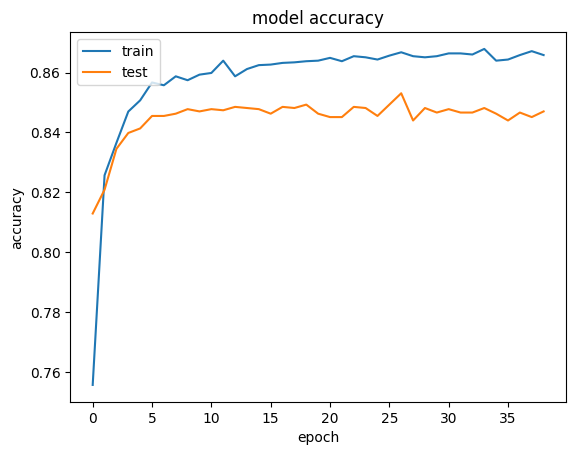

In [26]:
#Summarise history for accuracy:

plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('model accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend(['train','test'],loc='upper left')
plt.show()

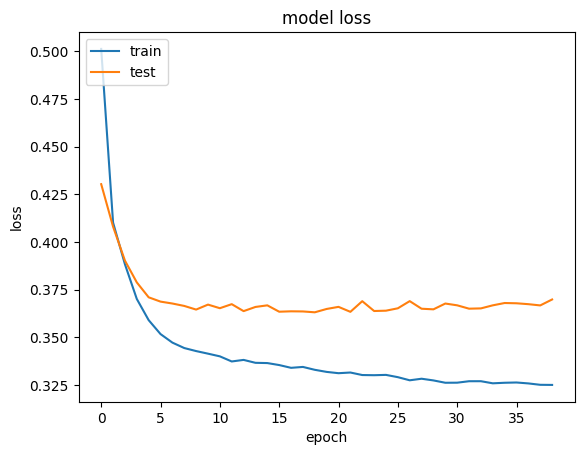

In [27]:
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.title('model loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train','test'],loc='upper left')
plt.show()

In [28]:
y_pred= classifier.predict(X_test)
y_pred=(y_pred>=0.5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [29]:
# Confusion metrics

from sklearn.metrics import confusion_matrix
cm= confusion_matrix(y_test,y_pred)
cm

array([[1541,   54],
       [ 228,  177]])

In [30]:
# Calculate accuracy

from sklearn.metrics import accuracy_score
score= accuracy_score(y_test,y_pred)
score

0.859

#### Get the weights




In [31]:
classifier.get_weights()

[array([[-0.19487476,  0.13552646, -0.46017778,  0.02456016,  0.36664703,
         -0.0271567 ,  0.13232872, -0.18611442,  0.06288417,  0.2363713 ,
         -0.71985775],
        [ 0.08575352, -0.01900633,  0.17643197, -0.32312104, -0.33898538,
          0.12040383, -0.82376647,  0.50929564, -0.5579725 ,  0.11150251,
         -0.3645168 ],
        [-0.26463604, -0.18525983, -0.3686538 ,  0.07513855,  0.39499724,
         -0.13861871,  0.01791464, -0.20436552, -0.12971447,  0.37925807,
         -0.35154355],
        [ 0.23086639, -0.12436666, -0.01701874, -0.26047558, -0.3634294 ,
         -0.36710486,  0.00773011, -0.6292644 , -0.20561631, -0.10661434,
          0.1908739 ],
        [ 0.9563359 ,  0.7175111 , -0.1325216 , -0.625192  ,  0.14441717,
         -1.1043277 , -0.4205496 , -0.4286488 ,  0.13064061,  0.51622313,
          0.01057589],
        [-0.02052777, -0.37524313,  0.29289925, -0.6097566 , -0.24353361,
          0.07466096, -0.14638822, -0.07196943,  0.09165482, -0.0229058

#### BLACK BOX v/s WHITE BOX MODEL

#### White box model

it is a model where we can clearly see and understand how the model makes decisions

the internal logic is transparent and intepretable

eg:
- Linear regression
- Logistic regression
- Decision trees
- Naive Bias


#### Black box model

it is a model whre the internal working is very difficult to intepret

we can see input and output , but understanding how the internal model reaches the decision is difficult

eg:
- Artificial neural network
- Deep learning model
- Random forest
- Gradient Boosting
